# 02 — Session summaries

**Mock data.** Same caveat as `01_explore.ipynb` — this validates the
summary computation pipeline, not real driving conclusions.

Computation logic lives in `src/session_summary.py`, not here — this
notebook is a thin display layer around it, deliberately, in case this
logic ever graduates into a scheduled Pi service later.

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

print("Python executable:", sys.executable)
print("PYTHONPATH env var:", repr(os.environ.get("PYTHONPATH")))

Python executable: /home/buvindu-suraweera/vehicle-telemetry-platform/analytics/.venv/bin/python
PYTHONPATH env var: None


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.session_summary import list_sessions, summarize_all_sessions

sns.set_theme(style="darkgrid")

## What sessions actually exist right now

Pulled dynamically rather than hardcoded — the dev DB has been fully
recreated at least once already, so session IDs/row counts from earlier
notebooks can't be assumed to still hold.

In [4]:
sessions = list_sessions()
sessions

,session_id,driver_id,started_at,notes,row_count
0,mock_001,driver_a,2026-07-16 12:37:48.224580+00:00,Mock data session,64619
1,live_001,driver_a,2026-07-16 12:37:48.227689+00:00,Live OBD session,0


## Compute summary stats per session

In [5]:
summary = summarize_all_sessions()
summary

,session_id,row_count,duration_s,avg_speed_kmh,max_speed_kmh,avg_rpm,max_rpm,avg_throttle_pct,max_throttle_pct,avg_coolant_temp_c,max_coolant_temp_c,avg_engine_load_pct,max_abs_accel_x,max_abs_accel_y
0,mock_001,64619,6476.524288,60.136582,90.0,3405.60105,4760.0,40.018337,69.9,84.995096,89.1,32.014572,1.285,0.457


## Quick visual comparison across sessions

Only meaningful once there's more than one session with real variation
— with a single mock session this is just a pipeline/rendering check.

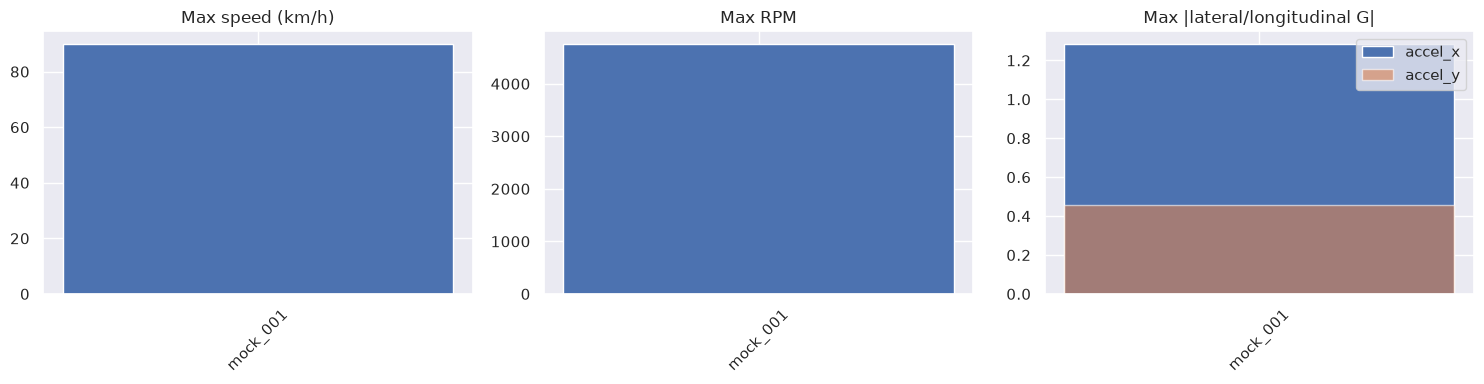

In [6]:
if len(summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].bar(summary["session_id"], summary["max_speed_kmh"])
    axes[0].set_title("Max speed (km/h)")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(summary["session_id"], summary["max_rpm"])
    axes[1].set_title("Max RPM")
    axes[1].tick_params(axis="x", rotation=45)

    axes[2].bar(summary["session_id"], summary["max_abs_accel_x"], label="accel_x")
    axes[2].bar(summary["session_id"], summary["max_abs_accel_y"], alpha=0.6, label="accel_y")
    axes[2].set_title("Max |lateral/longitudinal G|")
    axes[2].tick_params(axis="x", rotation=45)
    axes[2].legend()

    fig.tight_layout()
else:
    print("No sessions with data yet.")